# Visualize Augmentations & Data Generator

Inspect `JawKeypointSequenceDataset` and `ExperimentGroupedBatchSampler` before training.

Requires `../data/train.pkl` (run `Create Dataset/create_dataset.py` first).

In [10]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader

sys.path.insert(0, str(Path.cwd()))
from dataset import (
    JawKeypointSequenceDataset,
    get_geom_train_transforms,
    scale_keypoints_orig_to_target,
    ORIG_W,
    ORIG_H,
)
from sampler import ExperimentGroupedBatchSampler
from train import collate_batch

TRAIN_PKL = "../data/train.pkl"
WINDOW_SIZE = 8
IMG_H, IMG_W = 240, 320  # target H×W; CSV keypoints are x∈[0,640], y∈[0,480]
BATCH_SIZE = 4
SEED = 42

In [11]:
train_geom = get_geom_train_transforms(IMG_H, IMG_W)
ds = JawKeypointSequenceDataset(
    TRAIN_PKL,
    transform=train_geom,
    window_size=WINDOW_SIZE,
    img_h=IMG_H,
    img_w=IMG_W,
)
CENTER_INDEX = ds.center_index
sampler = ExperimentGroupedBatchSampler(
    ds.center_indices_for_sampler, BATCH_SIZE, seed=SEED
)
loader = DataLoader(ds, batch_sampler=sampler, collate_fn=collate_batch)
print(f"Dataset windows: {len(ds):,}")
print(f"Original CSV space: {ORIG_W}w × {ORIG_H}h  →  model space: {IMG_W}w × {IMG_H}h")
print(f"Center frame index in window: {CENTER_INDEX}")

Dataset windows: 1,429
Original CSV space: 640w × 480h  →  model space: 320w × 240h
Center frame index in window: 3


In [12]:
def denorm(img_t):
    """CHW tensor (ImageNet norm) → HWC uint8 for display."""
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    x = img_t.cpu().numpy().transpose(1, 2, 0)
    x = np.clip(x * std + mean, 0, 1)
    return (x * 255).astype(np.uint8)


# batch: (x, hm, kps_orig, kps_target, exp_ids, frames)
x, hm, kps_orig, kps_target, exp_ids, frames = next(iter(loader))
print("x:", tuple(x.shape))
print("heatmaps:", tuple(hm.shape))
print("keypoints_orig (640×480 CSV):", kps_orig[0].tolist())
print("keypoints_target (320×240 aug):", kps_target[0].tolist())
print("experiment_ids:", exp_ids.tolist())

x: (4, 8, 3, 240, 320)
heatmaps: (4, 2, 240, 320)
keypoints_orig (640×480 CSV): [[444.8489990234375, 304.2099914550781], [590.4869995117188, 330.6180114746094]]
keypoints_target (320×240 aug): [[223.9261016845703, 149.0271759033203], [297.2979431152344, 158.69802856445312]]
experiment_ids: [1, 1, 1, 1]


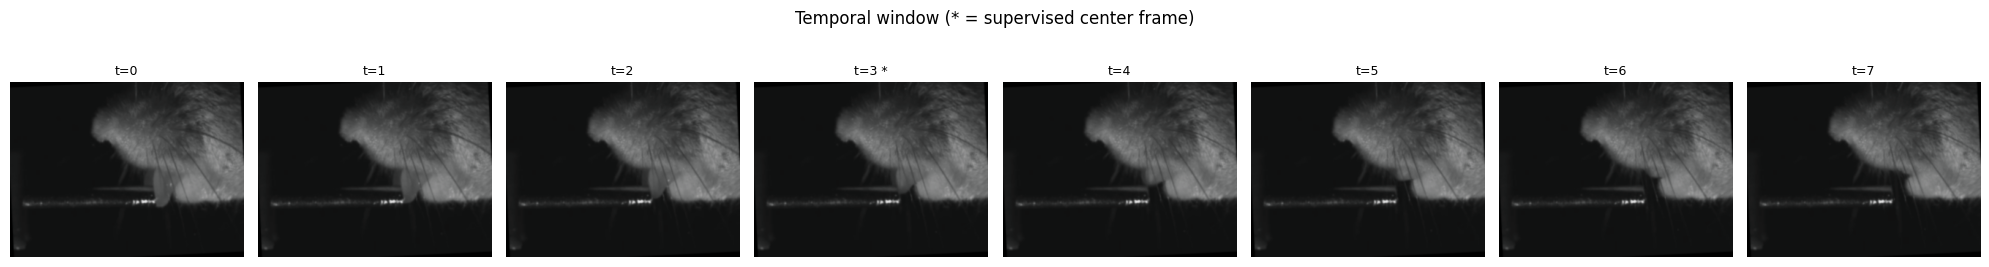

In [13]:
sample_idx = 0
seq = x[sample_idx]

# 8-frame sequence grid (* = supervised center frame)
fig, axes = plt.subplots(1, WINDOW_SIZE, figsize=(2.5 * WINDOW_SIZE, 3))
for t, ax in enumerate(axes):
    ax.imshow(denorm(seq[t]))
    ax.set_title(f"t={t}" + (" *" if t == CENTER_INDEX else ""), fontsize=9)
    ax.axis("off")
plt.suptitle("Temporal window (* = supervised center frame)")
plt.tight_layout()
plt.show()

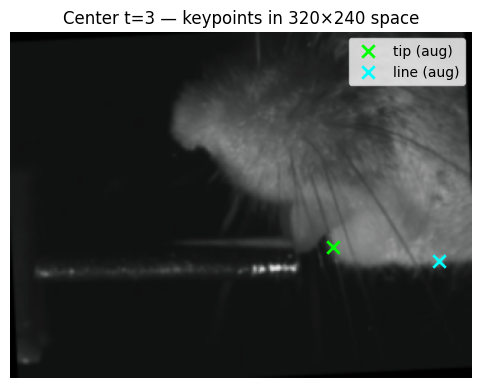

CSV tip (640×480): [444.8489990234375, 304.2099914550781]
Aug tip (320×240): [223.9261016845703, 149.0271759033203]
Resize-only tip (no rot/flip): (222.42449951171875, 152.10499572753906)


In [14]:
# Overlay augmented keypoints (lime=tip, cyan=line) on supervised center frame
sample_idx = 0
seq = x[sample_idx]
center_img = denorm(seq[CENTER_INDEX])

tip = kps_target[sample_idx, 0].numpy()  # x,y in 320×240 after aug
line = kps_target[sample_idx, 1].numpy()

# sanity: resize-only reference from CSV (no rotation/flip)
tip_resize_only = scale_keypoints_orig_to_target(
    [(kps_orig[sample_idx, 0, 0].item(), kps_orig[sample_idx, 0, 1].item()),
     (kps_orig[sample_idx, 1, 0].item(), kps_orig[sample_idx, 1, 1].item())],
    IMG_W, IMG_H,
)[0]

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.imshow(center_img, extent=(0, IMG_W, IMG_H, 0))
ax.scatter(tip[0], tip[1], c="lime", s=80, marker="x", linewidths=2, label="tip (aug)")
ax.scatter(line[0], line[1], c="cyan", s=80, marker="x", linewidths=2, label="line (aug)")
ax.set_xlim(0, IMG_W)
ax.set_ylim(IMG_H, 0)
ax.legend(loc="upper right")
ax.set_title(f"Center t={CENTER_INDEX} — keypoints in {IMG_W}×{IMG_H} space")
ax.axis("off")
plt.show()

print("CSV tip (640×480):", kps_orig[sample_idx, 0].tolist())
print("Aug tip (320×240):", tip.tolist())
print("Resize-only tip (no rot/flip):", tip_resize_only)

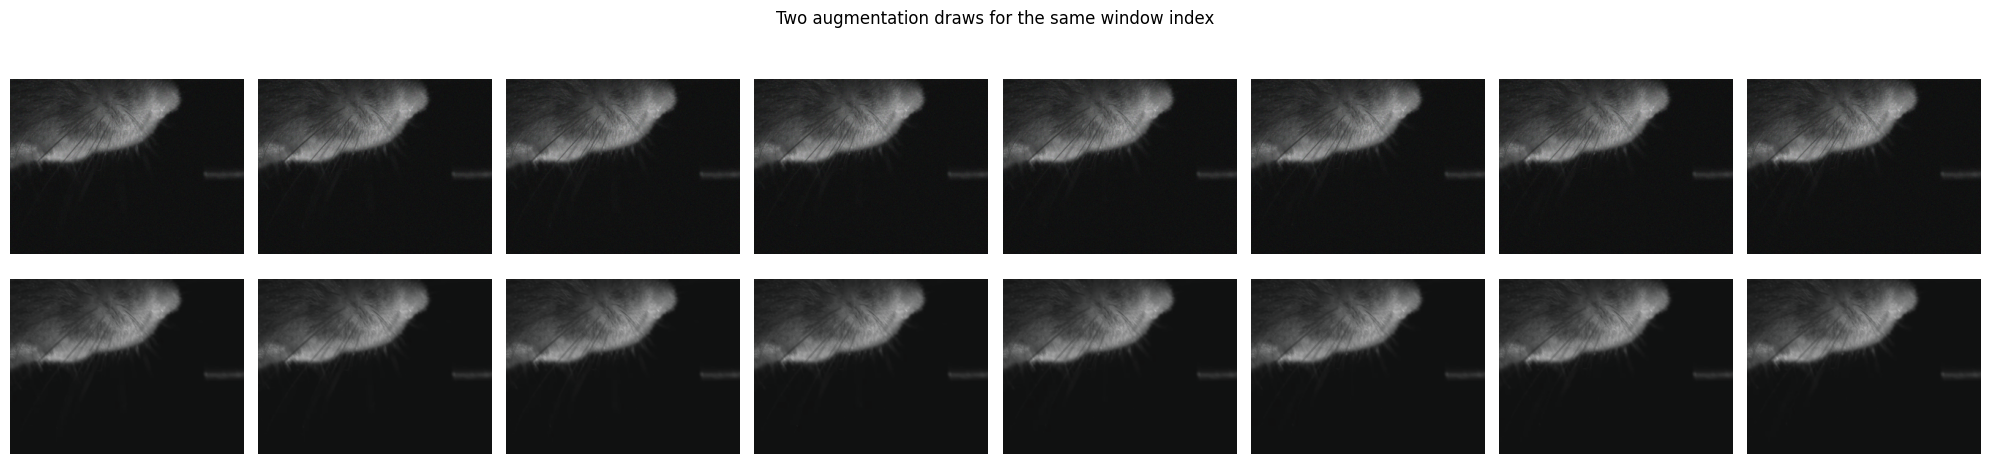

In [15]:
# Augmentation comparison: same index, two loader passes → different aug, same transform across 8 frames
idx = 0
a = ds[idx]
b = ds[idx]
fig, axes = plt.subplots(2, WINDOW_SIZE, figsize=(2.5 * WINDOW_SIZE, 5))
for row, item in enumerate([a, b]):
    seq_t = item[0]
    for t in range(WINDOW_SIZE):
        axes[row, t].imshow(denorm(seq_t[t]))
        axes[row, t].axis("off")
    axes[row, 0].set_ylabel(f"draw {row+1}", rotation=0, labelpad=40)
plt.suptitle("Two augmentation draws for the same window index")
plt.tight_layout()
plt.show()

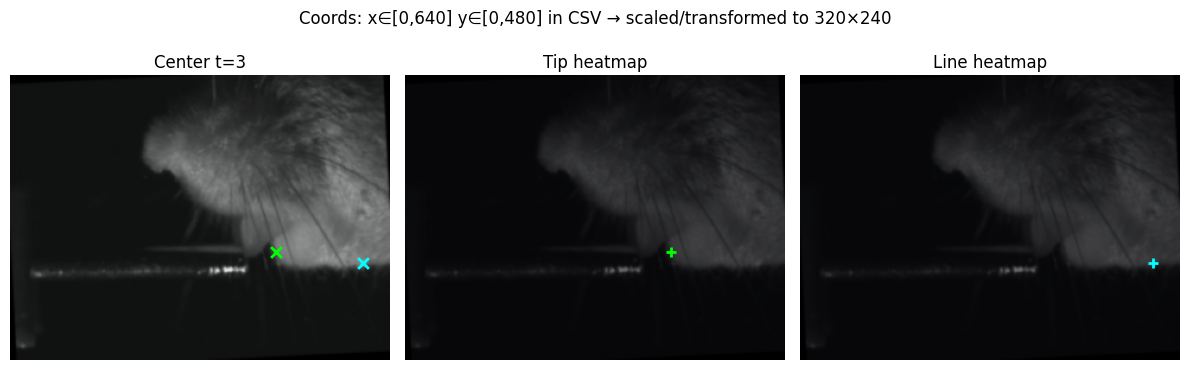

In [16]:
# Heatmap targets must peak at the same aug keypoints
hm_sample = hm[sample_idx].numpy()
center_img = denorm(seq[CENTER_INDEX])
tip = kps_target[sample_idx, 0].numpy()
line = kps_target[sample_idx, 1].numpy()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(center_img, extent=(0, IMG_W, IMG_H, 0))
axes[0].scatter(tip[0], tip[1], c="lime", s=60, marker="x", linewidths=2)
axes[0].scatter(line[0], line[1], c="cyan", s=60, marker="x", linewidths=2)
axes[0].set_xlim(0, IMG_W)
axes[0].set_ylim(IMG_H, 0)
axes[0].set_title(f"Center t={CENTER_INDEX}")
axes[0].axis("off")

for ax, ch, name, xy, color in zip(
    axes[1:],
    [0, 1],
    ["Tip heatmap", "Line heatmap"],
    [tip, line],
    ["lime", "cyan"],
):
    ax.imshow(center_img, extent=(0, IMG_W, IMG_H, 0))
    ax.imshow(hm_sample[ch], cmap="magma", alpha=0.55, vmin=0, vmax=1,
              extent=(0, IMG_W, IMG_H, 0))
    ax.scatter(xy[0], xy[1], c=color, s=60, marker="+", linewidths=2)
    ax.set_xlim(0, IMG_W)
    ax.set_ylim(IMG_H, 0)
    ax.set_title(name)
    ax.axis("off")

plt.suptitle("Coords: x∈[0,640] y∈[0,480] in CSV → scaled/transformed to 320×240")
plt.tight_layout()
plt.show()

In [17]:
# Sampler check: each batch has a single experiment_id
# batch = (x, hm, kps_orig, kps_target, exp_ids, frames)
for i, batch in enumerate(loader):
    exp_ids = batch[4].unique().tolist()
    print(f"batch {i}: experiment_ids={exp_ids}")
    if i >= 5:
        break

batch 0: experiment_ids=[1]
batch 1: experiment_ids=[1]
batch 2: experiment_ids=[1]
batch 3: experiment_ids=[1]
batch 4: experiment_ids=[1]
batch 5: experiment_ids=[1]


In [18]:
# Within-experiment shuffle: epoch 0 vs epoch 1 first-batch indices differ, same experiment
def first_batch_indices(epoch):
    sampler.set_epoch(epoch)
    batch = next(iter(DataLoader(ds, batch_sampler=sampler, collate_fn=collate_batch)))
    exp_id = batch[4][0].item()
    frame_nums = batch[5][:4].tolist()
    return exp_id, frame_nums

e0 = first_batch_indices(0)
e1 = first_batch_indices(1)
print("epoch 0 — experiment_id, first frames:", e0)
print("epoch 1 — experiment_id, first frames:", e1)

epoch 0 — experiment_id, first frames: (1, [89461, 89449, 124159, 67630])
epoch 1 — experiment_id, first frames: (2, [55549, 64045, 63937, 53375])
